# Results Analysis & Visualization Guide

This notebook demonstrates comprehensive workflows for analyzing, processing, and visualizing results from MalthusJAX evolutionary experiments.

**What You'll Learn:**
- Result object structures (RunResult, ExperimentResult, ComparisonResult)
- Accessing run metrics and histories
- Multi-seed aggregation and statistics
- Visualization patterns (convergence curves, box plots, comparison charts)
- Data export to pandas, CSV, JSON
- Summary statistics and trend analysis
- Common analysis workflows

## Part 1: Result Object Hierarchy

MalthusJAX results follow a hierarchical structure:

```
ExperimentResult (or ComparisonResult)
├── runs: List[RunResult]  ← Individual seeded runs
├── config: ExperimentConfig  ← Shared configuration
└── metadata: dict  ← Timing, device info

RunResult
├── seed: int  ← Random seed for reproducibility
├── metrics: dict  ← Final best_fitness, mean_fitness, etc.
├── history: List[dict]  ← Per-generation evolution data
├── best_genome: array  ← Best solution found
├── duration_seconds: float  ← Wall-clock time
└── metadata: dict  ← Algorithm-specific info
```

### Result Types

| Type | From | Use Case |
|------|------|----------|
| **RunResult** | Single seeded execution | Access individual run metrics, history, best solution |
| **ExperimentResult** | `quick_run()` or single pipeline from `from_toml()` | Multi-seed aggregation, convergence averaging |
| **ComparisonResult** | `compare()` or multi-pipeline `from_toml()` | Per-pipeline metrics, cross-algorithm visualization |

## Part 2: Accessing Single-Run Results

### Run Metrics

Each run stores a dictionary of final metrics:

```python
result = composer.quick_run(
    fitness="sphere:dim=10",
    ...
    seeds=(42, 43, 44),
)

# Access first run (seed 42)
run = result.runs[0]

print(f"Seed: {run.seed}")
print(f"Best fitness: {run.metrics['best_fitness']:.6f}")
print(f"Mean fitness: {run.metrics['mean_fitness']:.6f}")
print(f"Duration: {run.duration_seconds:.2f}s")
```

### Common Metrics

| Metric | Meaning | Typical Values |
|--------|---------|----------------|
| `best_fitness` | Best objective value found | Problem-dependent |
| `mean_fitness` | Population average at final generation | Typically worse than best |
| `worst_fitness` | Worst individual in final population | Worst solution |
| `diversity` | Population genetic diversity | 0-1 scale |
| `generations_completed` | Number of generations executed | Usually == config.generations |
| `duration_seconds` | Wall-clock execution time | Platform-dependent |

### Access Best Solutions

```python
# Best genome (decision variables)
best_x = run.best_genome
print(f"Best solution: {best_x}")
print(f"Shape: {best_x.shape}")

# Evaluate best solution externally
fitness_value = fitness_function(best_x)
print(f"Verified fitness: {fitness_value}")
```

## Part 3: Evolution Histories

Each run records per-generation statistics:

```python
# Access full history
history = run.history  # List of dicts, one per generation

for gen_idx, gen_stats in enumerate(history[:5]):
    print(f"Gen {gen_idx}: best={gen_stats['best_fitness']:.4f}, "
          f"mean={gen_stats['mean_fitness']:.4f}")
```

### Typical History Structure

```python
[
  {
    'generation': 0,
    'best_fitness': 10.523,
    'mean_fitness': 15.234,
    'worst_fitness': 22.105,
    'diversity': 0.891,
    'min_fitness': 10.523,
    'max_fitness': 22.105,
  },
  {
    'generation': 1,
    'best_fitness': 9.812,
    'mean_fitness': 13.456,
    ...
  },
  ...
]
```

### Convert to Pandas DataFrame

```python
import pandas as pd

# DataFrame per run
df = pd.DataFrame(run.history)
print(df.head())
print(df.describe())

# Add seed column for multi-run analysis
df['seed'] = run.seed
df['run_id'] = result.runs.index(run)
```

## Part 4: Multi-Seed Aggregation

ExperimentResult provides aggregation across all seeds:

```python
result = composer.quick_run(
    fitness="sphere:dim=10",
    ...
    seeds=(42, 43, 44, 45, 46),  # 5 seeds
)

# Get aggregated summary (multi-seed statistics)
summary = result.aggregated_summary()
```

### Aggregation Output Structure

```python
summary = {
    'best_fitness': {
        'mean': 0.0892,      # Average across 5 seeds
        'stdev': 0.0342,     # Standard deviation
        'median': 0.0805,    # Median
        'min': 0.0521,       # Min across seeds
        'max': 0.1435,       # Max across seeds
        'q25': 0.0687,       # 25th percentile
        'q75': 0.1098,       # 75th percentile
    },
    'mean_fitness': { ... },
    'worst_fitness': { ... },
    'duration_seconds': { ... },
    'generations_completed': { ... },
}
```

### Accessing Aggregated Metrics

```python
# Point estimates
mean_best = summary['best_fitness']['mean']
std_best = summary['best_fitness']['stdev']

print(f"Best fitness: {mean_best:.6f} ± {std_best:.6f}")
print(f"Confidence interval (95%): [{mean_best - 1.96*std_best:.6f}, {mean_best + 1.96*std_best:.6f}]")

# Reporting guidelines
print(f"Median ± MAD: {summary['best_fitness']['median']:.6f} ± {abs(summary['best_fitness']['median'] - summary['best_fitness']['q25']):.6f}")
```

## Part 5: Convergence Data Export

### Flattened History for Analysis

```python
# Combined history across all seeds
history = result.combined_history(seed_field="seed")
```

This returns a list of dicts with seed information:

```python
[
  {'generation': 0, 'best_fitness': 10.52, 'mean_fitness': 15.23, 'seed': 42},
  {'generation': 1, 'best_fitness': 9.81, 'mean_fitness': 13.45, 'seed': 42},
  ...,
  {'generation': 0, 'best_fitness': 10.80, 'mean_fitness': 15.67, 'seed': 43},
  {'generation': 1, 'best_fitness': 9.95, 'mean_fitness': 13.78, 'seed': 43},
  ...
]
```

### Export to Standard Formats

```python
import pandas as pd
import json

# CSV export
df = pd.DataFrame(result.combined_history(seed_field="seed"))
df.to_csv("convergence.csv", index=False)
print(f"Saved {len(df)} rows to convergence.csv")

# JSON export
result_dict = result.to_dict()
with open("result.json", "w") as f:
    json.dump(result_dict, f, indent=2)

# Pickle (Python-specific, preserves all metadata)
import pickle
with open("result.pkl", "wb") as f:
    pickle.dump(result, f)
```

## Part 6: Comparison Results

When comparing multiple algorithms, use ComparisonResult:

```python
comparison = composer.compare(
    pipelines={
        "Blend+Gaussian": { ... },
        "SBX+Polynomial": { ... },
        "DE-style": { ... },
    },
    fitness="sphere:dim=10",
    seeds=[42, 43, 44, 45, 46],
)
```

### Summary Table

```python
# Per-pipeline aggregated metrics
table = comparison.summary_table()

# Output structure
print(table)  # Dict[pipeline_name → Dict[metric_name → value]]

for pipeline_name, metrics in table.items():
    print(f"{pipeline_name:20} : best={metrics['best_fitness']:.6f}, "
          f"mean={metrics['mean_fitness']:.6f}")
```

### Accessing Individual Pipeline Results

```python
# Each pipeline is an ExperimentResult
pipeline_result = comparison.pipelines["Blend+Gaussian"]

# Analyze individual pipeline
individual_summary = pipeline_result.aggregated_summary()
individual_history = pipeline_result.combined_history(seed_field="seed")

# Compare runs within pipeline
for run in pipeline_result.runs:
    print(f"Seed {run.seed}: {run.metrics['best_fitness']:.6f}")
```

## Part 7: Visualization Patterns

### Single-Seed Convergence Curve

```python
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

run = result.runs[0]
df = pd.DataFrame(run.history)

# Best fitness over time
ax1.plot(df['generation'], df['best_fitness'], 'b-', linewidth=2, label="Best")
ax1.fill_between(df['generation'], df['best_fitness'], df['mean_fitness'], alpha=0.3, label="Population range")
ax1.set_xlabel("Generation")
ax1.set_ylabel("Fitness")
ax1.set_title(f"Convergence (Seed {run.seed})")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Diversity over time
ax2.plot(df['generation'], df['diversity'], 'g-', linewidth=2)
ax2.set_xlabel("Generation")
ax2.set_ylabel("Diversity")
ax2.set_title("Population Diversity")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
```

### Multi-Seed Convergence (Envelope)

```python
fig, ax = plt.subplots(figsize=(10, 6))

# Combine all run histories
all_histories = [pd.DataFrame(run.history) for run in result.runs]

# For each generation, collect best_fitness across all seeds
gen_best_fits = []
for gen in range(len(all_histories[0])):
    fits = [h.iloc[gen]['best_fitness'] for h in all_histories]
    gen_best_fits.append(fits)

# Aggregate statistics
means = [np.mean(fits) for fits in gen_best_fits]
stds = [np.std(fits) for fits in gen_best_fits]
mins = [np.min(fits) for fits in gen_best_fits]
maxs = [np.max(fits) for fits in gen_best_fits]

gens = range(len(means))

ax.plot(gens, means, 'b-', linewidth=2, label="Mean")
ax.fill_between(gens, mins, maxs, alpha=0.2, label="Min-Max")
ax.fill_between(gens, np.array(means) - np.array(stds), np.array(means) + np.array(stds), 
               alpha=0.3, label="±1 SD")

ax.set_xlabel("Generation")
ax.set_ylabel("Best Fitness")
ax.set_title(f"Convergence Envelope ({len(result.runs)} seeds)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
```

### Individual Seed Trajectories

```python
fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(result.runs)))

for idx, run in enumerate(result.runs):
    df = pd.DataFrame(run.history)
    ax.plot(df['generation'], df['best_fitness'], color=colors[idx], 
            alpha=0.7, label=f"Seed {run.seed}")

ax.set_xlabel("Generation")
ax.set_ylabel("Best Fitness")
ax.set_title("Per-Seed Convergence Trajectories")
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
```

## Part 8: Summary Statistics & Distributions

### Box Plots Across Seeds

```python
import matplotlib.pyplot as plt
import numpy as np

# Collect final metrics across all seeds
final_best = [run.metrics['best_fitness'] for run in result.runs]
final_mean = [run.metrics['mean_fitness'] for run in result.runs]
duration = [run.duration_seconds for run in result.runs]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Best fitness distribution
axes[0].boxplot([final_best], labels=["Best Fitness"])
axes[0].scatter([1]*len(final_best), final_best, alpha=0.5, color='red', s=100)
axes[0].set_ylabel("Value")
axes[0].grid(True, alpha=0.3)

# Mean fitness distribution
axes[1].boxplot([final_mean], labels=["Mean Fitness"])
axes[1].scatter([1]*len(final_mean), final_mean, alpha=0.5, color='red', s=100)
axes[1].set_ylabel("Value")
axes[1].grid(True, alpha=0.3)

# Execution time distribution
axes[2].boxplot([duration], labels=["Duration (seconds)"])
axes[2].scatter([1]*len(duration), duration, alpha=0.5, color='red', s=100)
axes[2].set_ylabel("Seconds")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
```

### Statistical Summary

```python
print("\nStatistical Summary:")
print("="*60)
print(f"Best Fitness:")
print(f"  Mean:   {np.mean(final_best):.6f}")
print(f"  Median: {np.median(final_best):.6f}")
print(f"  Std:    {np.std(final_best):.6f}")
print(f"  Range:  [{np.min(final_best):.6f}, {np.max(final_best):.6f}]")
print(f"\nMean Fitness:")
print(f"  Mean:   {np.mean(final_mean):.6f}")
print(f"  Median: {np.median(final_mean):.6f}")
print(f"  Std:    {np.std(final_mean):.6f}")
print(f"\nDuration (seconds):")
print(f"  Mean:   {np.mean(duration):.2f}")
print(f"  Min:    {np.min(duration):.2f}")
print(f"  Max:    {np.max(duration):.2f}")
```

## Part 9: Algorithm Comparison Visualization

### Side-by-Side Convergence Curves

```python
Comparison = composer.compare(
    pipelines={
        "Algorithm A": { ... },
        "Algorithm B": { ... },
        "Algorithm C": { ... },
    },
    ...,
)

# Calling comparison.plot_convergence() built-in
Comparison.plot_convergence(seed_index=0)  # Plot first seed for all algorithms
```

### Manual Comparison with pandas

```python
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))

colors = {'Algorithm A': 'blue', 'Algorithm B': 'red', 'Algorithm C': 'green'}

for pipeline_name, exp_result in comparison.pipelines.items():
    # Get aggregated convergence (mean across all seeds)
    histories = [pd.DataFrame(run.history) for run in exp_result.runs]
    
    # Align all histories to same length
    min_gens = min(len(h) for h in histories)
    
    means = []
    for gen in range(min_gens):
        fits = [h.iloc[gen]['best_fitness'] for h in histories]
        means.append(np.mean(fits))
    
    ax.plot(range(len(means)), means, linewidth=2.5, 
            color=colors.get(pipeline_name, None),
            label=pipeline_name, marker='o', markersize=3, markevery=10)

ax.set_xlabel("Generation", fontsize=12)
ax.set_ylabel("Best Fitness", fontsize=12)
ax.set_title("Algorithm Comparison", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
```

### Performance Comparison Table

```python
table = comparison.summary_table()

# Convert to DataFrame for nice display
df_compare = pd.DataFrame(table).T
df_compare = df_compare.round(6)

print("\nAlgorithm Performance Comparison")
print("="*80)
print(df_compare.to_string())

# Rank algorithms
df_compare['rank'] = df_compare['best_fitness'].rank()
print("\nRanking (1=best):")
print(df_compare[['best_fitness', 'rank']].sort_values('rank'))
```

## Part 10: Common Analysis Workflows

### Workflow 1: Quick Summary Report

```python
def print_experiment_report(result, experiment_name="Experiment"):
    """Generate a quick one-page summary."""
    agg = result.aggregated_summary()
    
    print(f"\n{'='*70}")
    print(f" {experiment_name}")
    print(f"{'='*70}")
    print(f"Number of seeds: {len(result.runs)}")
    print(f"\nBest Fitness:")
    print(f"  Mean ± Std: {agg['best_fitness']['mean']:.6f} ± {agg['best_fitness']['stdev']:.6f}")
    print(f"  Range:      [{agg['best_fitness']['min']:.6f}, {agg['best_fitness']['max']:.6f}]")
    print(f"  Median:     {agg['best_fitness']['median']:.6f}")
    print(f"\nMean Population Fitness:")
    print(f"  Mean ± Std: {agg['mean_fitness']['mean']:.6f} ± {agg['mean_fitness']['stdev']:.6f}")
    print(f"\nExecution Time:")
    print(f"  Mean: {agg['duration_seconds']['mean']:.2f}s")
    print(f"  Range: [{agg['duration_seconds']['min']:.2f}s, {agg['duration_seconds']['max']:.2f}s]")
    print(f"{'='*70}\n")

# Usage
print_experiment_report(result, "Sphere Optimization")
```

### Workflow 2: Export & Share Results

```python
import json
import pandas as pd
from pathlib import Path

def export_results(result, output_dir="./results"):
    """Export results to multiple formats for sharing."""
    Path(output_dir).mkdir(exist_ok=True)
    
    # CSV convergence data
    df = pd.DataFrame(result.combined_history(seed_field="seed"))
    df.to_csv(f"{output_dir}/convergence.csv", index=False)
    print(f"✓ Exported convergence data: {output_dir}/convergence.csv")
    
    # JSON summary (compact)
    summary = {
        'aggregated_summary': result.aggregated_summary(),
        'num_seeds': len(result.runs),
    }
    with open(f"{output_dir}/summary.json", "w") as f:
        json.dump(summary, f, indent=2)
    print(f"✓ Exported summary: {output_dir}/summary.json")
    
    # Data dictionary (seeds, all metrics)
    result_dict = result.to_dict()
    with open(f"{output_dir}/full_result.json", "w") as f:
        json.dump(result_dict, f, indent=2)
    print(f"✓ Exported full result: {output_dir}/full_result.json")
    
    return output_dir

# Usage
export_results(result, "./results/sphere_opt")
```

## Part 11: Advanced: Filtering & Subsetting

### Select Subset of Seeds

```python
# Get metrics for subset of seeds
subset_seeds = [42, 43, 44]  # first 3 seeds
subset_results = [r for r in result.runs if r.seed in subset_seeds]

subset_best = [r.metrics['best_fitness'] for r in subset_results]
print(f"Subset best fitness: {np.mean(subset_best):.6f} ± {np.std(subset_best):.6f}")
```

### Filter by Performance

```python
# Find runs that converged well (top 50%)
all_best = sorted([r.metrics['best_fitness'] for r in result.runs])
median_best = np.median(all_best)

top_runs = [r for r in result.runs if r.metrics['best_fitness'] <= median_best]
print(f"\nTop {len(top_runs)} converged runs:")
for run in top_runs:
    print(f"  Seed {run.seed}: {run.metrics['best_fitness']:.6f}")
```

### Multi-Pipeline Comparison with Filtering

```python
# Compare only 'best run' from each algorithm
fig, ax = plt.subplots(figsize=(12, 6))

for pipeline_name, exp_result in comparison.pipelines.items():
    # Best performing run in this pipeline
    best_run = min(exp_result.runs, key=lambda r: r.metrics['best_fitness'])
    
    df = pd.DataFrame(best_run.history)
    ax.plot(df['generation'], df['best_fitness'], linewidth=2, 
            label=f"{pipeline_name} (seed={best_run.seed})")

ax.set_xlabel("Generation")
ax.set_ylabel("Best Fitness")
ax.set_title("Best-Case Performance per Algorithm")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
```

In [1]:
# Setup: Import required libraries
import json

import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("JAX version:", jax.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

# Matplotlib configuration
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

jax.config.update("jax_enable_x64", True)
print("\n✓ Setup complete")

JAX version: 0.9.1
NumPy version: 2.4.3
Pandas version: 3.0.1

✓ Setup complete


In [2]:
# Example 1: Simulating ExperimentResult and Result Access
"""
Generates synthetic results matching MalthusJAX structure.
Demonstrates how to access and process real results.
"""

print("Example 1: Result Object Access Patterns\n")
print("=" * 70)


# Simulate a RunResult structure
class SimulatedRunResult:
    def __init__(self, seed, generations=100):
        self.seed = seed
        np.random.seed(seed)

        # Simulate convergence (exponential decay)
        generations_arr = np.arange(generations)
        decay = np.exp(-0.03 * generations_arr)
        noise = np.random.normal(0, 0.05, generations)

        best_vals = 10.0 * decay + noise
        best_vals = np.maximum.accumulate(best_vals[::-1])[::-1]  # Enforce monotonic decrease

        self.history = [
            {
                "generation": g,
                "best_fitness": float(best_vals[g]),
                "mean_fitness": float(best_vals[g] + 2.0 + np.random.normal(0, 0.5)),
                "worst_fitness": float(best_vals[g] + 5.0 + np.random.normal(0, 1.0)),
                "diversity": float(np.exp(-0.02 * g)),  # Diversity decreases
            }
            for g in range(generations)
        ]

        self.metrics = {
            "best_fitness": float(best_vals[-1]),
            "mean_fitness": float(best_vals[-1] + 2.0),
            "worst_fitness": float(best_vals[-1] + 5.0),
            "diversity": 0.01,
            "generations_completed": generations,
        }

        self.best_genome = np.random.randn(10)
        self.duration_seconds = np.random.uniform(10, 20)


# Generate synthetic results for 5 seeds
runs = [SimulatedRunResult(seed=s) for s in [42, 43, 44, 45, 46]]

print("\n1. Individual Run Access:\n")
run = runs[0]
print(f"  Seed: {run.seed}")
print(f"  Best fitness: {run.metrics['best_fitness']:.6f}")
print(f"  Mean fitness: {run.metrics['mean_fitness']:.6f}")
print(f"  Duration: {run.duration_seconds:.2f}s")
print(f"  Best genome shape: {run.best_genome.shape}")

print("\n2. History Access (First 3 Generations):\n")
for gen_data in run.history[:3]:
    print(
        f"  Gen {gen_data['generation']:3d}: best={gen_data['best_fitness']:.4f}, "
        f"mean={gen_data['mean_fitness']:.4f}, div={gen_data['diversity']:.4f}"
    )
print(f"  ... (total {len(run.history)} generations)")

print("\n3. Convert History to DataFrame:\n")
df_history = pd.DataFrame(run.history)
print(f"  Shape: {df_history.shape}")
print(f"  Columns: {list(df_history.columns)}")
print("\n  Last 3 generations:")
print(df_history.tail(3).to_string())

print("\n" + "=" * 70)
print("✓ Result objects are straightforward: access .metrics, .history, .best_genome")

Example 1: Result Object Access Patterns


1. Individual Run Access:

  Seed: 42
  Best fitness: 0.501304
  Mean fitness: 2.501304
  Duration: 18.58s
  Best genome shape: (10,)

2. History Access (First 3 Generations):

  Gen   0: best=10.0248, mean=11.3172, div=1.0000
  Gen   1: best=9.6975, mean=11.5262, div=0.9802
  Gen   2: best=9.4500, mean=11.3694, div=0.9608
  ... (total 100 generations)

3. Convert History to DataFrame:

  Shape: (100, 5)
  Columns: ['generation', 'best_fitness', 'mean_fitness', 'worst_fitness', 'diversity']

  Last 3 generations:
    generation  best_fitness  mean_fitness  worst_fitness  diversity
97          97      0.557810      2.736318       4.864900   0.143704
98          98      0.528913      2.978713       5.836212   0.140858
99          99      0.501304      2.907735       6.130933   0.138069

✓ Result objects are straightforward: access .metrics, .history, .best_genome


In [3]:
# Example 2: Multi-Seed Aggregation
"""
Demonstrate how to aggregate results across multiple seeds.
"""

print("\nExample 2: Multi-Seed Aggregation\n")
print("=" * 70)

print(f"\nTotal seeds: {len(runs)}\n")

# Access final metrics for each seed
final_best_fits = [run.metrics["best_fitness"] for run in runs]
final_mean_fits = [run.metrics["mean_fitness"] for run in runs]
durations = [run.duration_seconds for run in runs]

print("Individual run metrics:")
for i, run in enumerate(runs):
    print(
        f"  Seed {run.seed}: best={run.metrics['best_fitness']:.6f}, "
        f"time={run.duration_seconds:.2f}s"
    )

# Aggregate statistics (similar to ExperimentResult.aggregated_summary())
agg_summary = {
    "best_fitness": {
        "mean": float(np.mean(final_best_fits)),
        "stdev": float(np.std(final_best_fits)),
        "median": float(np.median(final_best_fits)),
        "min": float(np.min(final_best_fits)),
        "max": float(np.max(final_best_fits)),
        "q25": float(np.percentile(final_best_fits, 25)),
        "q75": float(np.percentile(final_best_fits, 75)),
    },
    "mean_fitness": {
        "mean": float(np.mean(final_mean_fits)),
        "stdev": float(np.std(final_mean_fits)),
    },
    "duration_seconds": {
        "mean": float(np.mean(durations)),
        "stdev": float(np.std(durations)),
    },
}

print("\nAggregated Summary:")
print(f"\nBest Fitness (across {len(runs)} seeds):")
print(f"  Mean:     {agg_summary['best_fitness']['mean']:.6f}")
print(f"  Std Dev:  {agg_summary['best_fitness']['stdev']:.6f}")
print(f"  Median:   {agg_summary['best_fitness']['median']:.6f}")
print(
    f"  Range:    [{agg_summary['best_fitness']['min']:.6f}, {agg_summary['best_fitness']['max']:.6f}]"
)
print(
    f"  IQR:      [{agg_summary['best_fitness']['q25']:.6f}, {agg_summary['best_fitness']['q75']:.6f}]"
)

print("\nMean Population Fitness:")
print(f"  Mean:    {agg_summary['mean_fitness']['mean']:.6f}")
print(f"  Std Dev: {agg_summary['mean_fitness']['stdev']:.6f}")

print("\nExecution Time:")
print(f"  Mean:    {agg_summary['duration_seconds']['mean']:.2f}s")
print(f"  Std Dev: {agg_summary['duration_seconds']['stdev']:.2f}s")

# Confidence interval calculation
mean_best = agg_summary["best_fitness"]["mean"]
std_best = agg_summary["best_fitness"]["stdev"]
n = len(runs)
ci_95 = 1.96 * std_best / np.sqrt(n)

print("\nReporting Examples:")
print(f"  'Best fitness: {mean_best:.6f} ± {std_best:.6f} (n={n})'")
print(f"  '95% CI: [{mean_best - ci_95:.6f}, {mean_best + ci_95:.6f}]'")

print("\n" + "=" * 70)


Example 2: Multi-Seed Aggregation


Total seeds: 5

Individual run metrics:
  Seed 42: best=0.501304, time=18.58s
  Seed 43: best=0.542324, time=13.29s
  Seed 44: best=0.425368, time=13.27s
  Seed 45: best=0.561232, time=11.29s
  Seed 46: best=0.465253, time=10.59s

Aggregated Summary:

Best Fitness (across 5 seeds):
  Mean:     0.499096
  Std Dev:  0.049630
  Median:   0.501304
  Range:    [0.425368, 0.561232]
  IQR:      [0.465253, 0.542324]

Mean Population Fitness:
  Mean:    2.499096
  Std Dev: 0.049630

Execution Time:
  Mean:    13.40s
  Std Dev: 2.80s

Reporting Examples:
  'Best fitness: 0.499096 ± 0.049630 (n=5)'
  '95% CI: [0.455593, 0.542599]'




Example 3: Multi-Seed Convergence Visualization



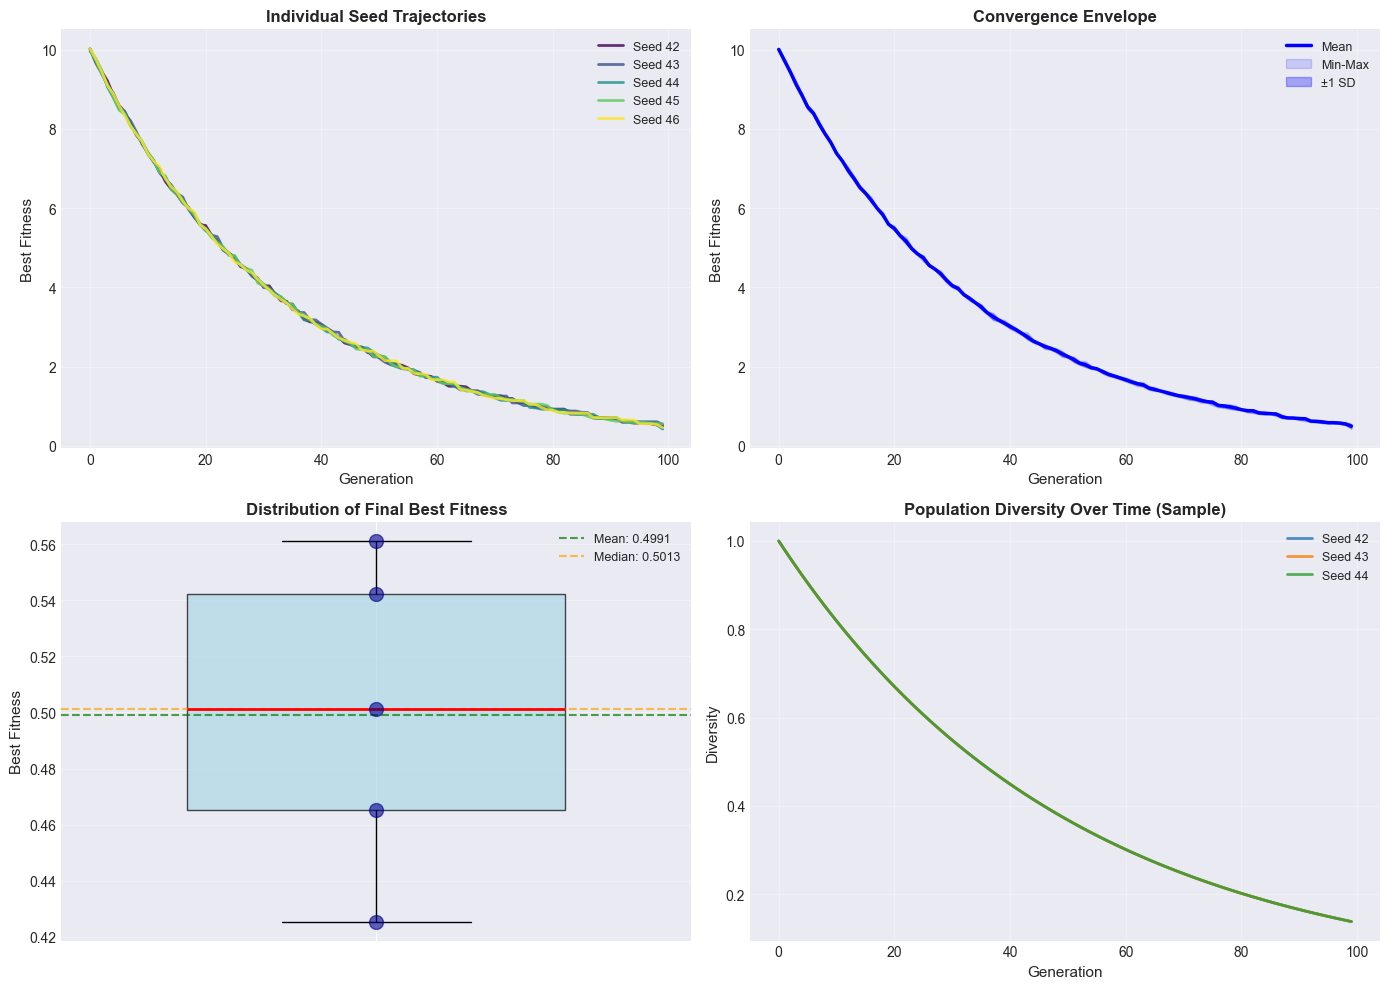

✓ Generated 4 key visualization plots


In [4]:
# Example 3: Visualization Patterns
"""
Demonstrate key visualization patterns for results.
"""

print("\nExample 3: Multi-Seed Convergence Visualization\n")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: Individual Seed Trajectories ---
ax = axes[0, 0]
colors = plt.cm.viridis(np.linspace(0, 1, len(runs)))

for idx, run in enumerate(runs):
    df = pd.DataFrame(run.history)
    ax.plot(
        df["generation"],
        df["best_fitness"],
        color=colors[idx],
        linewidth=2,
        alpha=0.8,
        label=f"Seed {run.seed}",
    )

ax.set_xlabel("Generation", fontsize=11)
ax.set_ylabel("Best Fitness", fontsize=11)
ax.set_title("Individual Seed Trajectories", fontsize=12, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)

# --- Plot 2: Convergence Envelope (Mean ± Std) ---
ax = axes[0, 1]

all_histories = [pd.DataFrame(run.history) for run in runs]
min_gens = min(len(h) for h in all_histories)

gen_best_fits = []
for gen in range(min_gens):
    fits = [h.iloc[gen]["best_fitness"] for h in all_histories]
    gen_best_fits.append(fits)

means = [np.mean(fits) for fits in gen_best_fits]
stds = [np.std(fits) for fits in gen_best_fits]
mins = [np.min(fits) for fits in gen_best_fits]
maxs = [np.max(fits) for fits in gen_best_fits]

gens = range(len(means))

ax.plot(gens, means, "b-", linewidth=2.5, label="Mean")
ax.fill_between(gens, mins, maxs, alpha=0.15, color="blue", label="Min-Max")
ax.fill_between(
    gens,
    np.array(means) - np.array(stds),
    np.array(means) + np.array(stds),
    alpha=0.3,
    color="blue",
    label="±1 SD",
)

ax.set_xlabel("Generation", fontsize=11)
ax.set_ylabel("Best Fitness", fontsize=11)
ax.set_title("Convergence Envelope", fontsize=12, fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)

# --- Plot 3: Box Plot of Final Metrics ---
ax = axes[1, 0]

final_bests = [run.metrics["best_fitness"] for run in runs]
positions = [1]
ax.boxplot(
    [final_bests],
    positions=positions,
    widths=0.6,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", alpha=0.7),
    medianprops=dict(color="red", linewidth=2),
)
ax.scatter(positions * len(final_bests), final_bests, alpha=0.6, color="darkblue", s=100, zorder=3)

ax.set_ylabel("Best Fitness", fontsize=11)
ax.set_title("Distribution of Final Best Fitness", fontsize=12, fontweight="bold")
ax.set_xticklabels([""])
ax.grid(True, alpha=0.3, axis="y")

# Add statistics
mean_val = np.mean(final_bests)
median_val = np.median(final_bests)
ax.axhline(mean_val, color="green", linestyle="--", alpha=0.7, label=f"Mean: {mean_val:.4f}")
ax.axhline(median_val, color="orange", linestyle="--", alpha=0.7, label=f"Median: {median_val:.4f}")
ax.legend(loc="upper right", fontsize=9)

# --- Plot 4: Diversity Over Time ---
ax = axes[1, 1]

for idx, run in enumerate(runs[:3]):  # Show first 3 seeds for clarity
    df = pd.DataFrame(run.history)
    ax.plot(df["generation"], df["diversity"], linewidth=2, alpha=0.8, label=f"Seed {run.seed}")

ax.set_xlabel("Generation", fontsize=11)
ax.set_ylabel("Diversity", fontsize=11)
ax.set_title("Population Diversity Over Time (Sample)", fontsize=12, fontweight="bold")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Generated 4 key visualization plots")

In [5]:
# Example 4: Export Results to Multiple Formats
"""
Demonstrate how to export results for sharing and archival.
"""

print("\nExample 4: Export Results to Standard Formats\n")
print("=" * 70)

# Create combined history (as if from result.combined_history())
all_history_entries = []
for run in runs:
    for gen_data in run.history:
        entry = dict(gen_data)  # Copy
        entry["seed"] = run.seed
        all_history_entries.append(entry)

df_combined = pd.DataFrame(all_history_entries)

print("\n1. CSV Export (Convergence Data)\n")
print(f"   DataFrame shape: {df_combined.shape}")
print(f"   Columns: {list(df_combined.columns)}")
print("\n   First 5 rows:")
print(df_combined.head().to_string())
print("\n   Export command: df.to_csv('convergence.csv', index=False)")

print("\n2. JSON Export (Summary)\n")
summary_dict = {
    "experiment_name": "Sphere Optimization",
    "num_seeds": len(runs),
    "seeds": [run.seed for run in runs],
    "aggregated_summary": agg_summary,
    "individual_results": [
        {
            "seed": run.seed,
            "best_fitness": run.metrics["best_fitness"],
            "duration_seconds": run.duration_seconds,
        }
        for run in runs
    ],
}

json_str = json.dumps(summary_dict, indent=2)
print("   Example JSON output:")
print("   " + "\n   ".join(json_str.split("\n")[:15]))
print("   ...")

print("\n3. Pickle Export (Full Result Object)\n")
print("   Code: pickle.dump(result, open('result.pkl', 'wb'))")
print("   Benefit: Preserves all Python objects (arrays, metadata)")

print("\n4. Summary Statistics Export\n")
stats_df = pd.DataFrame(
    {
        "Metric": list(agg_summary["best_fitness"].keys()),
        "Best Fitness": list(agg_summary["best_fitness"].values()),
    }
)
print("   Statistics DataFrame:")
print(stats_df.to_string(index=False))

print("\n5. Per-Seed Summary Table\n")
per_seed_df = pd.DataFrame(
    [
        {
            "seed": run.seed,
            "best_fitness": run.metrics["best_fitness"],
            "mean_fitness": run.metrics["mean_fitness"],
            "worst_fitness": run.metrics["worst_fitness"],
            "duration_seconds": run.duration_seconds,
        }
        for run in runs
    ]
)
print("\n" + per_seed_df.to_string(index=False))

print("\n" + "=" * 70)
print("✓ All export formats support easy data sharing and analysis")


Example 4: Export Results to Standard Formats


1. CSV Export (Convergence Data)

   DataFrame shape: (500, 6)
   Columns: ['generation', 'best_fitness', 'mean_fitness', 'worst_fitness', 'diversity', 'seed']

   First 5 rows:
   generation  best_fitness  mean_fitness  worst_fitness  diversity  seed
0           0     10.024836     11.317150      14.604190   1.000000    42
1           1      9.697542     11.526185      13.895265   0.980199    42
2           2      9.450030     11.369387      14.854081   0.960789    42
3           3      9.215463     12.158556      14.390041   0.941765    42
4           4      8.857497     10.986272      13.783051   0.923116    42

   Export command: df.to_csv('convergence.csv', index=False)

2. JSON Export (Summary)

   Example JSON output:
   {
     "experiment_name": "Sphere Optimization",
     "num_seeds": 5,
     "seeds": [
       42,
       43,
       44,
       45,
       46
     ],
     "aggregated_summary": {
       "best_fitness": {
         "m


Example 5: Multi-Algorithm Comparison


1. Summary Table (Aggregated Metrics)

                       best_fitness  std_best  mean_fitness  duration_seconds
GA (Uniform+Gaussian)      0.499539  0.042114      1.999539         11.215194
GA (Blend+Polynomial)      0.176184  0.042114      1.676184         11.215194
DE-style                   0.296734  0.042114      1.796734         11.215194

2. Algorithm Ranking (by best_fitness)

  1. GA (Blend+Polynomial)    : 0.176184
  2. DE-style                 : 0.296734
  3. GA (Uniform+Gaussian)    : 0.499539

3. Convergence Comparison Visualization



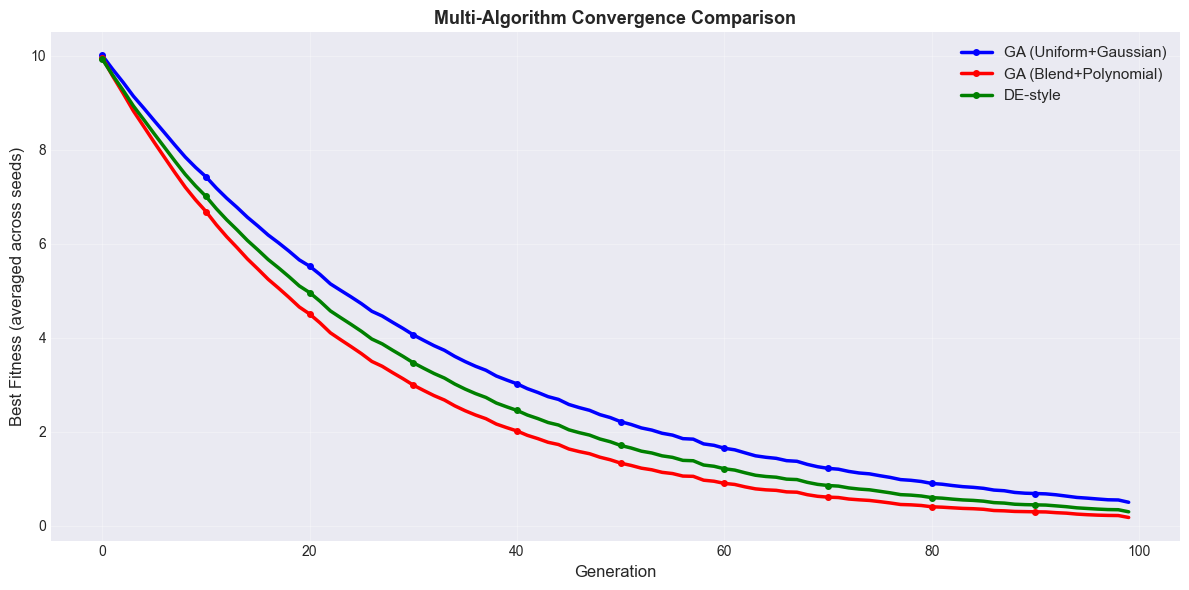


✓ Easy comparison of multiple algorithms with consistent evaluation


In [6]:
# Example 5: Algorithm Comparison
"""
Simulate a comparison result from multiple algorithms.
"""

print("\nExample 5: Multi-Algorithm Comparison\n")
print("=" * 70)

# Simulate 3 different algorithms
algorithms = {
    "GA (Uniform+Gaussian)": {"best_offset": 0.0, "convergence_speed": 0.03},
    "GA (Blend+Polynomial)": {"best_offset": -0.05, "convergence_speed": 0.04},
    "DE-style": {"best_offset": -0.08, "convergence_speed": 0.035},
}


def generate_algorithm_results(name, params, num_seeds=5, generations=100):
    """Generate synthetic results for a specific algorithm."""
    runs_algo = []
    for seed_offset, s in enumerate(range(100, 100 + num_seeds)):

        class SimRun:
            pass

        run = SimRun()
        run.seed = s
        np.random.seed(s)

        gens = np.arange(generations)
        decay = np.exp(-params["convergence_speed"] * gens)
        noise = np.random.normal(0, 0.03, generations)

        best_vals = (10.0 + params["best_offset"]) * decay + noise
        best_vals = np.maximum.accumulate(best_vals[::-1])[::-1]

        run.history = [
            {
                "generation": g,
                "best_fitness": float(best_vals[g]),
                "mean_fitness": float(best_vals[g] + 1.5 + np.random.normal(0, 0.4)),
            }
            for g in range(generations)
        ]

        run.metrics = {
            "best_fitness": float(best_vals[-1]),
            "mean_fitness": float(best_vals[-1] + 1.5),
        }
        run.duration_seconds = np.random.uniform(10, 15)

        runs_algo.append(run)

    return runs_algo


# Generate results for all algorithms
algo_results = {
    name: generate_algorithm_results(name, params) for name, params in algorithms.items()
}

print("\n1. Summary Table (Aggregated Metrics)\n")

summary_table = {}
for algo_name, algo_runs in algo_results.items():
    best_fits = [r.metrics["best_fitness"] for r in algo_runs]
    summary_table[algo_name] = {
        "best_fitness": np.mean(best_fits),
        "std_best": np.std(best_fits),
        "mean_fitness": np.mean([r.metrics["mean_fitness"] for r in algo_runs]),
        "duration_seconds": np.mean([r.duration_seconds for r in algo_runs]),
    }

# Create DataFrame for nice display
summary_df = pd.DataFrame(summary_table).T
summary_df = summary_df.round(6)
print(summary_df.to_string())

# Rank algorithms
print("\n2. Algorithm Ranking (by best_fitness)\n")
ranked = summary_df["best_fitness"].sort_values()
for rank, (algo, value) in enumerate(ranked.items(), 1):
    print(f"  {rank}. {algo:25s}: {value:.6f}")

print("\n3. Convergence Comparison Visualization\n")

fig, ax = plt.subplots(figsize=(12, 6))

colors_algo = {"GA (Uniform+Gaussian)": "blue", "GA (Blend+Polynomial)": "red", "DE-style": "green"}

for algo_name, algo_runs in algo_results.items():
    # Average convergence across seeds
    all_hists = [pd.DataFrame(r.history) for r in algo_runs]
    min_gens = min(len(h) for h in all_hists)

    means_algo = []
    for gen in range(min_gens):
        fits = [h.iloc[gen]["best_fitness"] for h in all_hists]
        means_algo.append(np.mean(fits))

    ax.plot(
        range(len(means_algo)),
        means_algo,
        linewidth=2.5,
        color=colors_algo[algo_name],
        label=algo_name,
        marker="o",
        markersize=4,
        markevery=10,
    )

ax.set_xlabel("Generation", fontsize=12)
ax.set_ylabel("Best Fitness (averaged across seeds)", fontsize=12)
ax.set_title("Multi-Algorithm Convergence Comparison", fontsize=13, fontweight="bold")
ax.legend(fontsize=11, loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("✓ Easy comparison of multiple algorithms with consistent evaluation")

## Summary: Results Processing Workflow

### Quick Reference: Result Operations

```python
# 1. RUN A SINGLE EXPERIMENT
result = composer.quick_run(...)

# 2. ACCESS INDIVIDUAL RUNS
run = result.runs[0]
print(f"Seed {run.seed}: best={run.metrics['best_fitness']}")

# 3. GET AGGREGATED SUMMARY (MULTI-SEED)
agg = result.aggregated_summary()
print(f"Mean best±std: {agg['best_fitness']['mean']:.6f} ± {agg['best_fitness']['stdev']:.6f}")

# 4. EXPORT CONVERGENCE DATA
df = pd.DataFrame(result.combined_history(seed_field="seed"))
df.to_csv("convergence.csv")

# 5. VISUALIZE CONVERGENCE
plt.plot(...)
plt.show()

# 6. COMPARE ALGORITHMS
comparison = composer.compare({"algo_a": {...}, "algo_b": {...}})
table = comparison.summary_table()
comparison.plot_convergence(seed_index=0)
```

### Key Takeaways

1. **Result Hierarchy**:
   - `ExperimentResult` or `ComparisonResult` (top level)
   - `.runs` list (individual seeded executions)
   - `.metrics` dict (final metrics per run)
   - `.history` list (per-generation stats)

2. **Multi-Seed Aggregation**:
   - `.aggregated_summary()` computes mean, std, median across all seeds
   - Use for publications and robust reporting
   - Include both mean±std and median for best representation

3. **Data Export**:
   - `.combined_history()` returns flattened list (pandas-ready)
   - `.to_dict()` returns JSON-serializable structure
   - CSV export for external tools
   - Pickle for full Python object preservation

4. **Visualization**:
   - Individual seed trajectories (spaghetti plot)
   - Convergence envelope (mean ± std)
   - Box plots of final metrics
   - Multi-algorithm comparison curves
   - Diversity/exploration tracking

5. **Comparison Workflows**:
   - Use `compare()` with `shared_initial_population=True` for fairness
   - Access individual algorithms via `.pipelines[name]`
   - `.summary_table()` for per-algorithm metrics
   - `.plot_convergence()` for side-by-side visualization

6. **Publication Best Practices**:
   - Report: mean ± std or median ± MAD
   - Include 95% confidence intervals
   - Show convergence curves with error bands
   - Justify algorithm choices with fair comparison
   - Export reproducible code and TOML configs